In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("/content/sales.csv", encoding = "latin1")

In [9]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [11]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [13]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [15]:
df['Order Year']=df['Order Date'].dt.year
df['Order Month']=df['Order Date'].dt.month

df['Shipping Delays'] = (df['Ship Date']-df['Order Date']).dt.days

df['Profit Margin']=df['Profit']/df['Sales']

In [18]:
df[['Order Date','Order Year','Order Month','Ship Date','Shipping Delays','Sales','Profit','Profit Margin']].head()

,Order Date,Order Year,Order Month,Ship Date,Shipping Delays,Sales,Profit,Profit Margin
0,2016-11-08,2016,11,2016-11-11,3,261.9600,41.9136,0.1600
1,2016-11-08,2016,11,2016-11-11,3,731.9400,219.5820,0.3000
2,2016-06-12,2016,6,2016-06-16,4,14.6200,6.8714,0.4700
3,2015-10-11,2015,10,2015-10-18,7,957.5775,-383.0310,-0.4000
4,2015-10-11,2015,10,2015-10-18,7,22.3680,2.5164,0.1125


In [19]:
df[['Sales','Profit','Profit Margin','Discount']].describe()

,Sales,Profit,Profit Margin,Discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.120314,0.156203
std,623.245101,234.260108,0.466754,0.206452
min,0.444000,-6599.978000,-2.750000,0.000000
25%,17.280000,1.728750,0.075000,0.000000
50%,54.490000,8.666500,0.270000,0.200000
75%,209.940000,29.364000,0.362500,0.200000
max,22638.480000,8399.976000,0.500000,0.800000


In [20]:
# Z-score formula: (value - mean) / standard deviation
df['Sales Z-Score'] = (df['Sales'] - np.mean(df['Sales'])) / np.std(df['Sales'])

# Flag rows where Sales is an outlier
outliers = df[np.abs(df['Sales Z-Score']) > 3]
print(f"Number of outlier orders (by Sales): {len(outliers)}")
outliers[['Order ID', 'Sales', 'Profit', 'Sales Z-Score']].head(10)

Number of outlier orders (by Sales): 127


,Order ID,Sales,Profit,Sales Z-Score
27,US-2015-150630,3083.4300,-1665.0522,4.578800
165,CA-2014-139892,8159.9520,-1359.9920,12.724514
251,CA-2016-145625,3347.3700,636.0003,5.002314
262,US-2014-106992,3059.9820,-509.9970,4.541176
263,US-2014-106992,2519.9580,-251.9958,3.674661
318,CA-2014-164973,3991.9800,1995.9900,6.036646
353,CA-2016-129714,4355.1680,1415.4296,6.619412
399,CA-2016-108987,2396.2656,-317.1528,3.476186
487,CA-2014-154627,2735.9520,341.9940,4.021242
509,CA-2015-145352,6354.9500,3177.4750,9.828234


In [21]:
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly_sales.head()


,Order Year,Order Month,Sales
0,2014,1,14236.895
1,2014,2,4519.892
2,2014,3,55691.009
3,2014,4,28295.345
4,2014,5,23648.287


In [22]:
monthly_sales['Date'] = pd.to_datetime(monthly_sales['Order Year'].astype(str) + '-' + monthly_sales['Order Month'].astype(str) + '-01')
monthly_sales = monthly_sales.sort_values('Date')

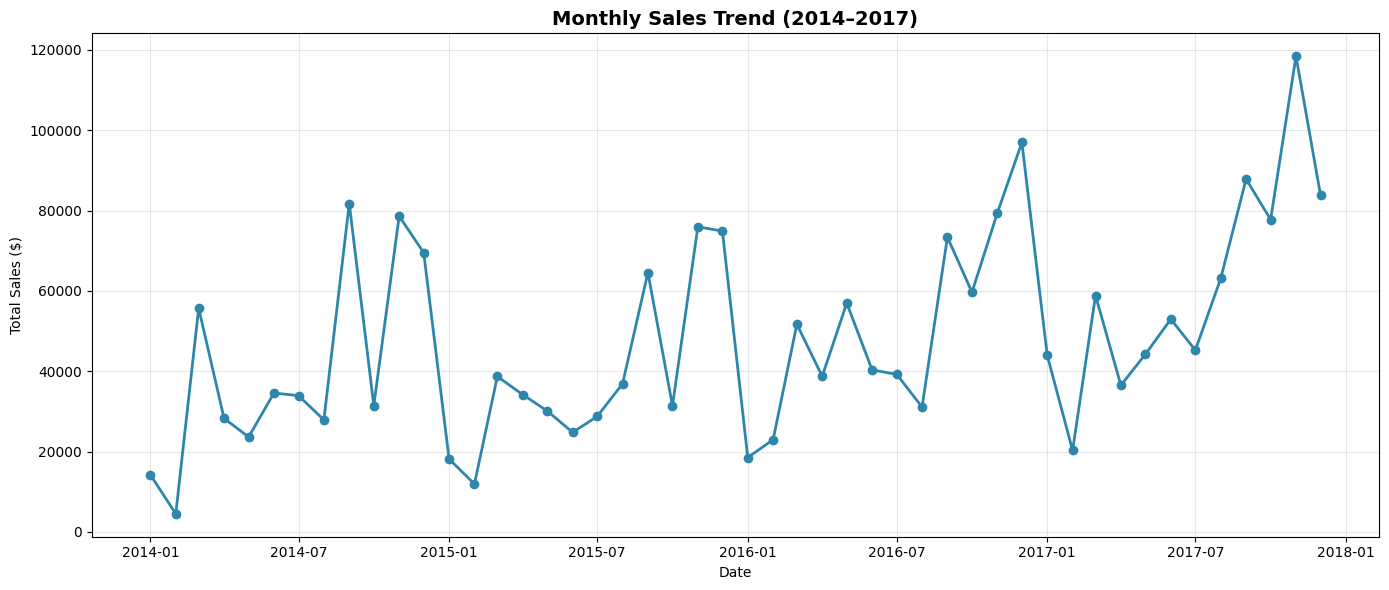

In [23]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], marker='o', color='#2E86AB', linewidth=2)
plt.title('Monthly Sales Trend (2014–2017)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
category_region_profit = df.pivot_table(
    values='Profit',
    index='Category',
    columns='Region',
    aggfunc='sum'
)
category_region_profit

Region,Central,East,South,West
Category,,,,
Furniture,-2871.0494,3046.1658,6771.2061,11504.9503
Office Supplies,8879.9799,41014.5791,19986.3928,52609.8490
Technology,33697.4320,47462.0351,19991.8314,44303.6496


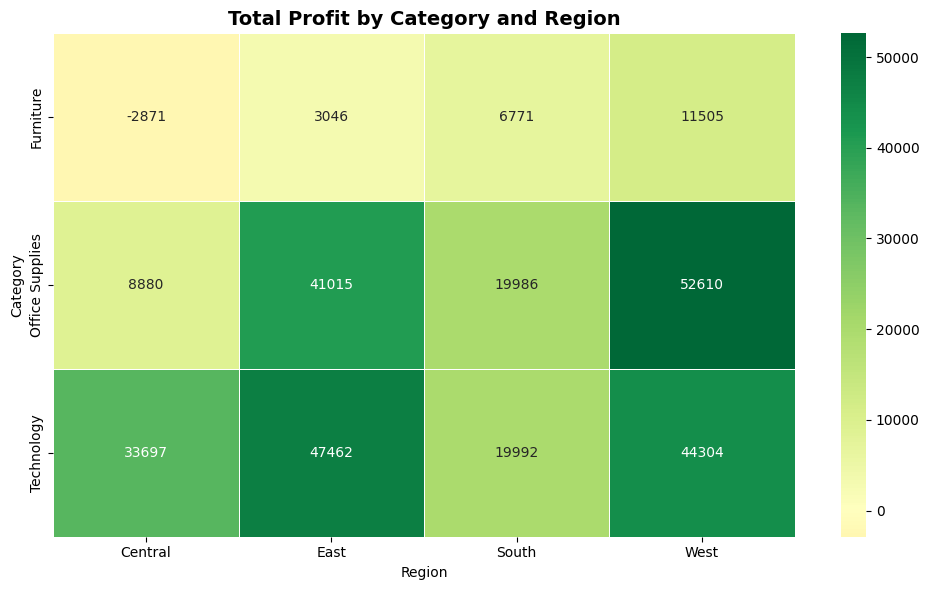

In [25]:
plt.figure(figsize=(10, 6))
sns.heatmap(category_region_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Total Profit by Category and Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

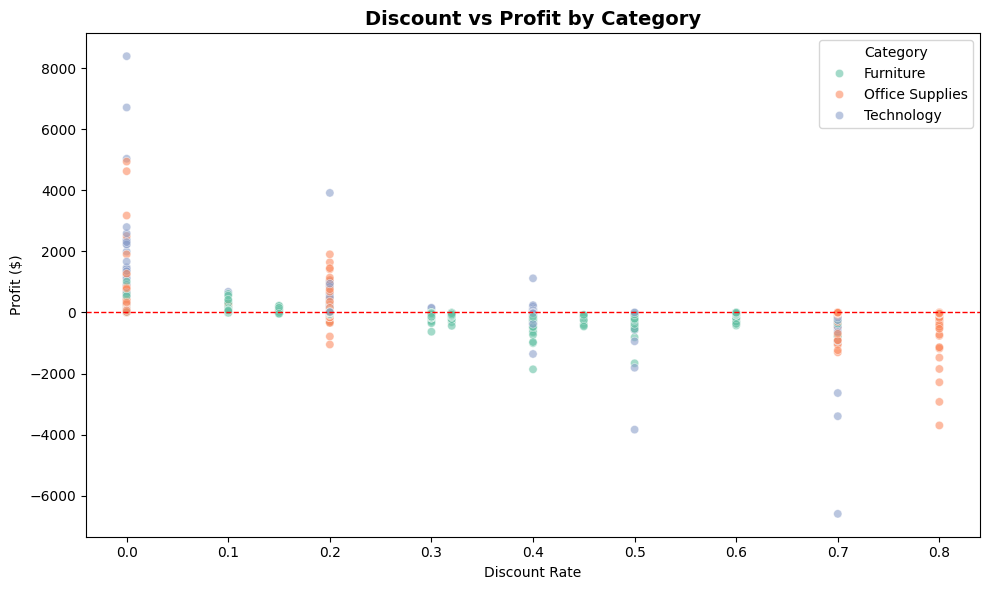

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6, palette='Set2')
plt.title('Discount vs Profit by Category', fontsize=14, fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

In [27]:
df['Discount Range'] = pd.cut(df['Discount'], bins=[-0.01, 0, 0.2, 0.4, 0.6, 0.8],
                                labels=['0%', '1-20%', '21-40%', '41-60%', '61-80%'])

avg_profit_by_discount = df.groupby('Discount Range', observed=True)['Profit'].mean().reset_index()
avg_profit_by_discount

,Discount Range,Profit
0,0%,66.900292
1,1-20%,26.501571
2,21-40%,-77.864055
3,41-60%,-134.624160
4,61-80%,-98.348741


/tmp/ipykernel_491/2808385168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_profit_by_discount, x='Discount Range', y='Profit', palette=colors)


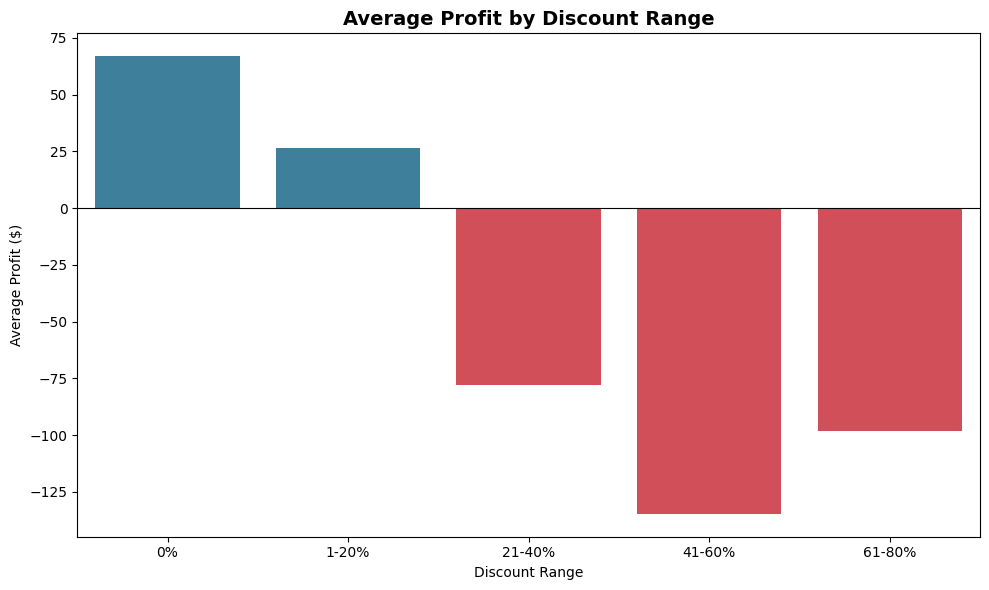

In [28]:
plt.figure(figsize=(10, 6))
colors = ['#2E86AB' if x >= 0 else '#E63946' for x in avg_profit_by_discount['Profit']]
sns.barplot(data=avg_profit_by_discount, x='Discount Range', y='Profit', palette=colors)
plt.title('Average Profit by Discount Range', fontsize=14, fontweight='bold')
plt.xlabel('Discount Range')
plt.ylabel('Average Profit ($)')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [29]:
product_profit = df.groupby('Product Name')['Profit'].sum().reset_index()
product_profit = product_profit.sort_values('Profit', ascending=False)

top_10_profitable = product_profit.head(10)
top_10_lossmaking = product_profit.tail(10).sort_values('Profit')

print(top_10_profitable)
print(top_10_lossmaking)

                                           Product Name      Profit
404               Canon imageCLASS 2200 Advanced Copier  25199.9280
650   Fellowes PB500 Electric Punch Plastic Comb Bin...   7753.0390
805                Hewlett Packard LaserJet 3310 Copier   6983.8836
400                  Canon PC1060 Personal Laser Copier   4570.9347
787   HP Designjet T520 Inkjet Large Format Printer ...   4094.9766
165                   Ativa V4110MDD Micro-Cut Shredder   3772.9461
19     3D Systems Cube Printer, 2nd Generation, Magenta   3717.9714
1276  Plantronics Savi W720 Multi-Device Wireless He...   3696.2820
895                Ibico EPK-21 Electric Binding System   3345.2823
1840                  Zebra ZM400 Thermal Label Printer   3343.5360
                                           Product Name     Profit
475           Cubify CubeX 3D Printer Double Head Print -8879.9704
985           Lexmark MX611dhe Monochrome Laser Printer -4589.9730
476           Cubify CubeX 3D Printer Triple Head P

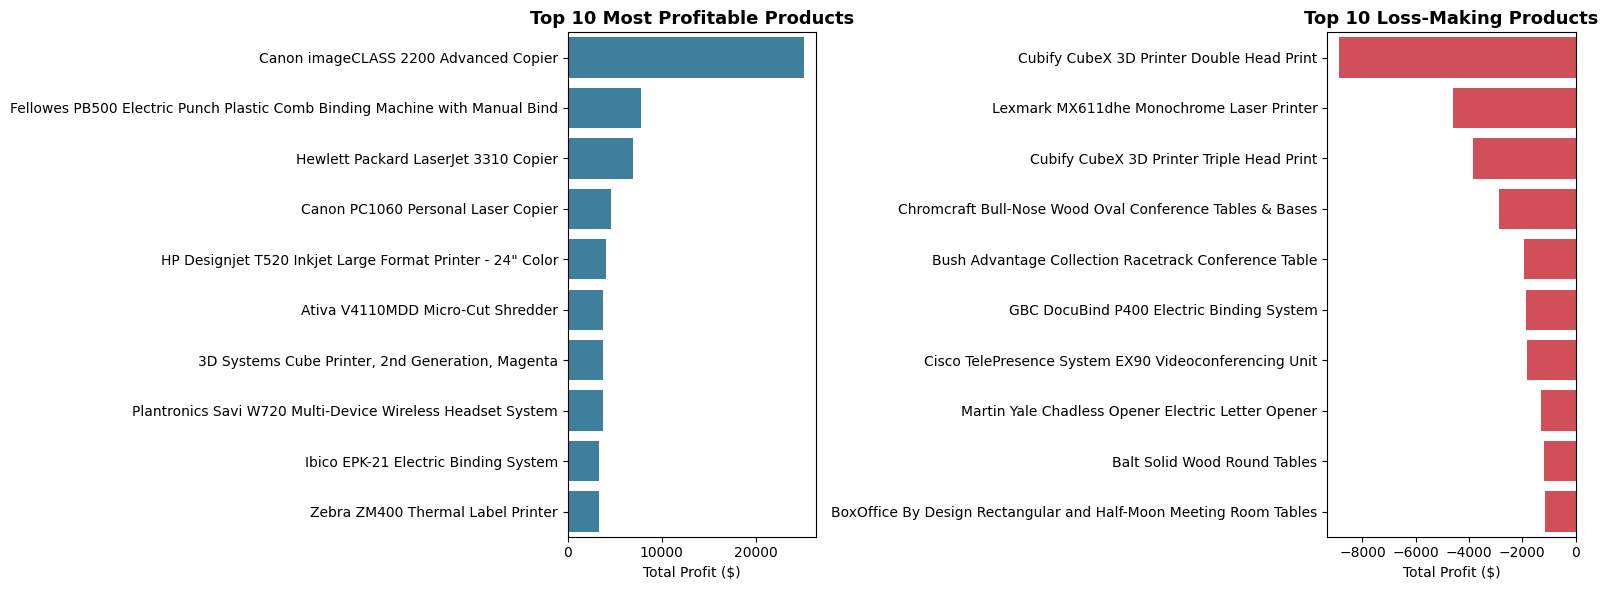

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top profitable products
sns.barplot(data=top_10_profitable, y='Product Name', x='Profit', ax=axes[0], color='#2E86AB')
axes[0].set_title('Top 10 Most Profitable Products', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')
axes[0].set_ylabel('')

# Top loss-making products
sns.barplot(data=top_10_lossmaking, y='Product Name', x='Profit', ax=axes[1], color='#E63946')
axes[1].set_title('Top 10 Loss-Making Products', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Profit ($)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()